
<img src="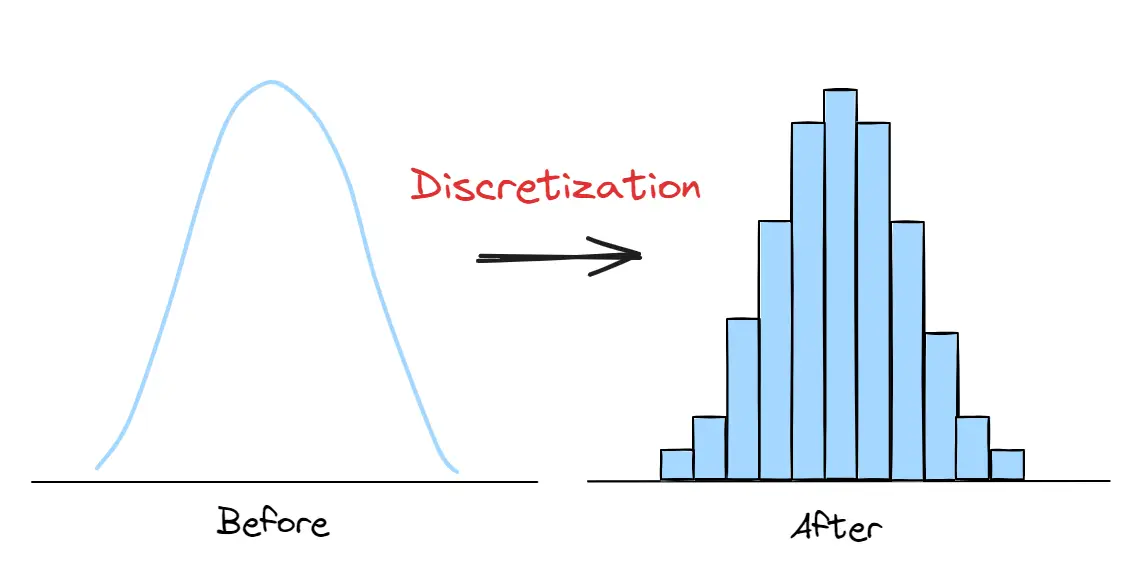" width="500">




### Numerical to Categorical Conversion

* **Purpose:** Used to convert numerical data into categorical data when discrete intervals make more sense.
* **Example (App Downloads):** 193, 12, 9000, 1 million, 2 billion $\rightarrow$ Converted into bins: `100+`, `1000+`, `10000+`, `1million+`, `1billion+`.

#### Core Methods
* **Discretisation / Binning**
* **Binarisation**

#### Why Use It?
1. To handle outliers better.
2. To improve the value spread.

---

### Types of Binning

#### A. Unsupervised Binning
1. **Equal Width Binning (Uniform Binning)**
2. **Equal Frequency Binning (Quantile Binning)**
3. **K-Means Binning**

#### B. Supervised Binning
1. **Decision Tree Binning**

#### C. Custom Binning

---

### Unsupervised Binning Breakdown

#### 1. Equal Width Binning (Uniform Binning)
* **Formula:** $\text{Width} = \frac{\text{Max} - \text{Min}}{\text{No. of Bins}}$
* **Example:** * Age data: 0, 27, 32, 39, 46, 81, 100
  * Bins = 10
  * $\text{Width} = \frac{100 - 0}{10} = 10$
  * Created Intervals: `0-10`, `10-20`, ..., `90-100`
* **Output:** Each bin's frequency is plotted.

#### 2. Equal Frequency Binning (Quantile Binning)
* **Mechanism:** Every bin contains the exact same percentage of total observations (e.g., if Bins = 10, each bin contains 10% of the data).
* **Example:** Bin 1: 0–10th percentile, Bin 2: 10th–20th percentile ... Bin 10: 90th–100th percentile.
* **Note:** Width of the bins can be different, but the frequency (count) inside each bin is identical.
* **Advantage:** Value spread becomes uniform. This is the default approach in sklearn and is used more than equal width binning.

#### 3. KMeans Binning
Uses a clustering algorithm to group numerical values based on similarity.

* **Step 1:** Randomly assign centroids.
* **Step 2:** Calculate the distance between each data point and every centroid.
* **Step 3:** Assign each data point to its closest centroid's cluster.
* **Step 4:** Shift the centroid's position to the mean value of its cluster.
* **Step 5:** Repeat steps 2 to 4 until the centroid positions stabilize and stop changing.
* **Result:** The final centroid values define the bins.
```

In [69]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('../Data sets/titanic.csv', usecols=['Age','Fare','Survived'])

In [51]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [52]:
df = df.dropna()

In [53]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [54]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [55]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [56]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [9]:
m = DecisionTreeClassifier()

m.fit(X_train,Y_train)

pred = m.predict(X_test)

accuracy_score(pred, Y_test)

0.6293706293706294

In [10]:
print(np.mean(cross_val_score(DecisionTreeClassifier(), X,Y,cv=10,scoring='accuracy')))

0.6289123630672926


# Binning(discretization)

In [38]:
# we make this transform ourselves

KBinsAge = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile') #changing n_bins can change accuracy
KBinsFare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [39]:
T = ColumnTransformer([
    ('t1',KBinsAge,[0]), #0 coz in X age has index 0 
    ('t2',KBinsFare,[1]) #...
])

In [40]:
X_train_T = T.fit_transform(X_train)
X_test_T= T.transform(X_test)

C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [41]:
m = DecisionTreeClassifier()
m.fit(X_train,Y_train)
pred2 = m.predict(X_test)
accuracy_score(pred2, Y_test)

0.6223776223776224

In [47]:
X_T = T.fit_transform(X)
print(np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=10,scoring='accuracy')))

0.6246870109546165


C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## Now lets make a function which reveals the before and after plot

In [118]:
def Discretize(bin,strategy):
    KBinsAge = KBinsDiscretizer(n_bins=bin,encode='ordinal',strategy=strategy) #changing n_bins can change accuracy
    KBinsFare = KBinsDiscretizer(n_bins=bin,encode='ordinal',strategy=strategy)

    T = ColumnTransformer([
    ('t1',KBinsAge,[0]), #0 coz in X age has index 0 
    ('t2',KBinsFare,[1]) #...
    ])

    X_T = T.fit_transform(X)
    X_T= pd.DataFrame(X_T)

    m = DecisionTreeClassifier()

    fit, axes = plt.subplots(1,2, figsize=(14,5))

    sns.histplot(X.iloc[:,0],ax=axes[0])
    axes[0].set_title('Before')

    sns.histplot(X_T.iloc[:,0],ax=axes[1])
    axes[1].set_title('After')
    plt.tight_layout()


    fit, axes = plt.subplots(1,2, figsize=(14,5))
    
    sns.histplot(X.iloc[:,1],ax=axes[0])
    axes[0].set_title('Before')

    sns.histplot(X_T.iloc[:,1],ax=axes[1])
    axes[1].set_title('After')
    plt.tight_layout()

    
    # sns.histplot(X['Fare'],ax=axes[1])

C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\luqma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


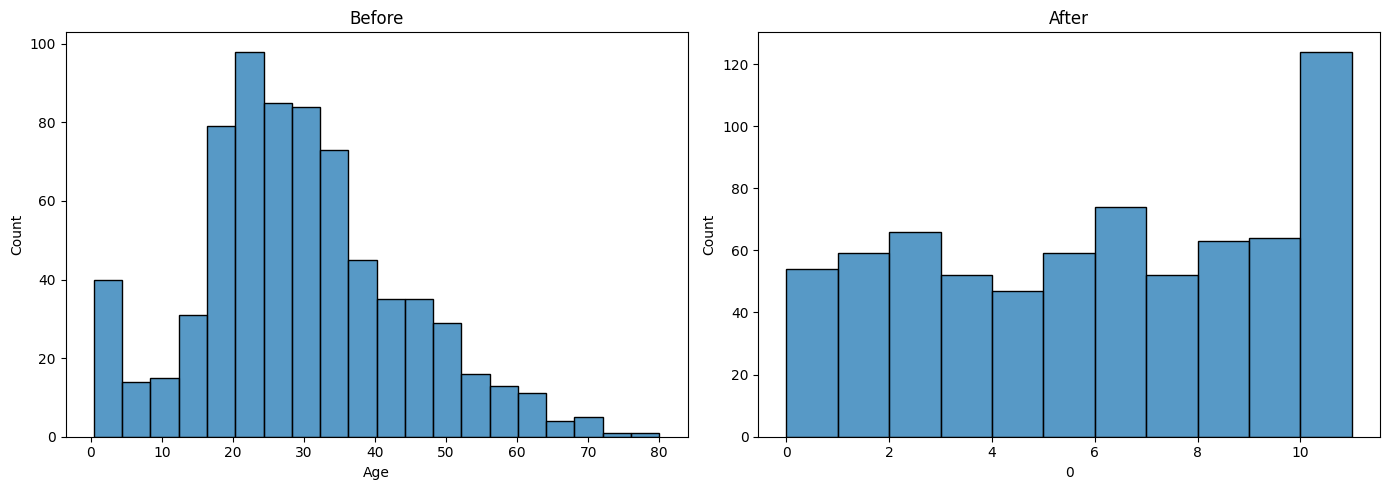

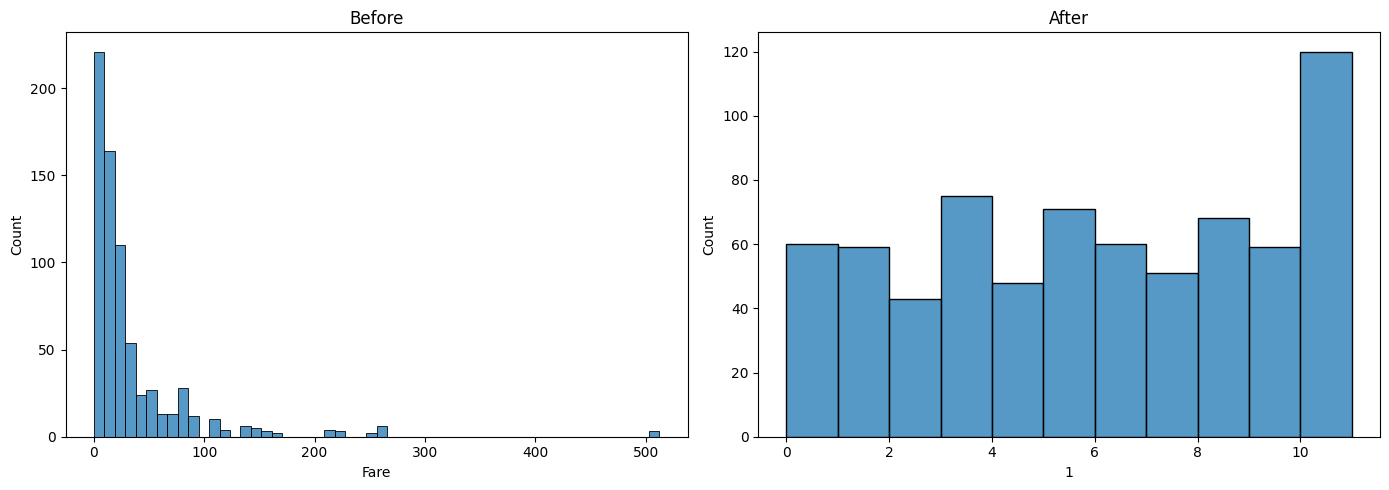

In [122]:
Discretize(12,'quantile')

# Binerization

continous numerical -> binary value(0,1)

anual income > 12l (taxable) = 1g
anual income <12l (not taxable) = 0

use case: img processing

color pexels: (I)intensity = (0,255)

t = threshold value = 175
I > t = 1
I < t = 0

converted to black and white!

sklearn: Binerizer